# Assignment Sesi 15
Nama: Faraday Barr Fatahillah

Instruksi

Anda bekerja sebagai data analyst di perusahaan properti. Tim riset meminta Anda membangun model awal untuk memprediksi harga median rumah (kolom MedHouseVal) berdasarkan fitur-fitur demografis dan geografis di distrik-distrik California.

**Task 1 — Eksplorasi Data Awal**
1. Load dataset dan tampilkan 5 baris pertama dengan df.head().
2. Tampilkan informasi tipe data dan jumlah missing values dengan df.info() dan df.isnull().sum().
3. Tampilkan statistik deskriptif kolom numerik dengan df.describe().
4. Buat scatter plot antara kolom MedInc (median income) dan MedHouseVal. Tambahkan judul "Pendapatan Median vs Harga Rumah" serta label pada sumbu x dan y.
5. Tulis 2 kalimat interpretasi di cell markdown: apakah ada pola linear yang terlihat?

In [1]:
from sklearn.datasets import fetch_california_housing  

In [2]:
#Task 1.1
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = fetch_california_housing(as_frame=True).frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
#Task 1.2
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.isna().sum().sort_values(ascending=False)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [5]:
#Task 1.3
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


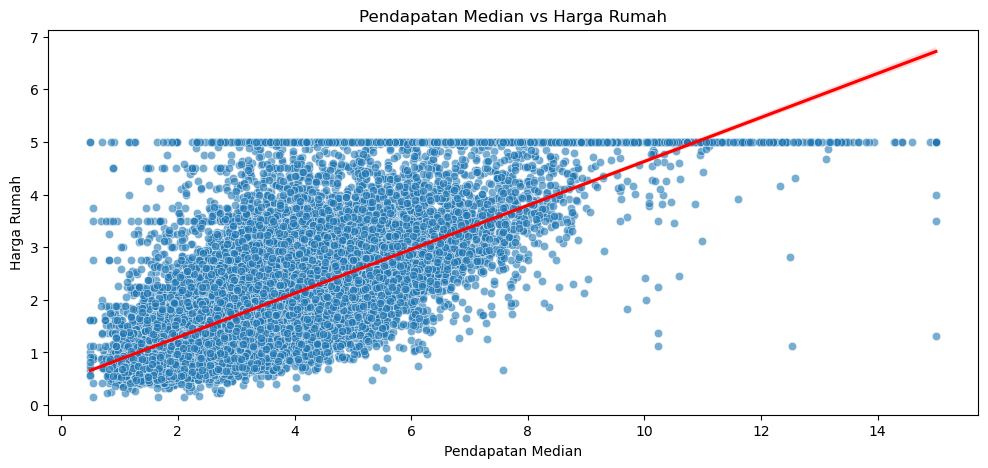

In [6]:
#Task 1.4
plt.figure(figsize=(12,5))

sns.scatterplot(data=df, x='MedInc', y='MedHouseVal', alpha=0.6)
sns.regplot(data=df, x='MedInc', y='MedHouseVal', scatter=False, color='red')
plt.title('Pendapatan Median vs Harga Rumah')
plt.xlabel('Pendapatan Median')
plt.ylabel('Harga Rumah')

plt.show()

**#Task 1.5**\
Data menunjukkan ada hubungan positif yamg signifikan antara median pendapatan penduduk dengan harga rumah yang dimiliki. Semakin besar median pendapatan penduduk, semakin tinggi harga rumah yang dimiliki.

**Task 2 — Simple Linear Regression**
1. Pisahkan fitur dan target: X = kolom MedInc saja, y = kolom MedHouseVal.
2. Bagi data menjadi training dan test set (80:20) menggunakan train_test_split dengan random_state=42.
3. Latih model LinearRegression dari sklearn.linear_model.
4. Tampilkan nilai intercept dan koefisien model.
5. Hitung dan cetak empat metrik berikut pada test set: MAE, MSE, RMSE (akar dari MSE), dan R2 Score.
6. Buat scatter plot actual vs predicted pada test set. Tambahkan garis diagonal y = x sebagai referensi perfect prediction.

In [7]:
#Task 2.1
X = df[['MedInc']]
y = df['MedHouseVal']

In [8]:
#Task 2.2
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.8)

In [9]:
#Task 2.3
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression().fit(X_train, y_train)
y_pred = reg_model.predict(X_test)
y_pred_train = reg_model.predict(X_train)

In [10]:
#Task 2.4
print(f'Koefisien: {reg_model.coef_}')
print(f'Nilai Intercept: {reg_model.intercept_}')

Koefisien: [0.41933849]
Nilai Intercept: 0.4445972916907881


In [11]:
#Task 2.5
print(f'Metrik Test Set')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2: {r2_score(y_test, y_pred)}')

Metrik Test Set
MAE: 0.629908653009376
MSE: 0.7091157771765548
RMSE: 0.8420901241414454
R2: 0.45885918903846656


In [12]:
print(f'Metrik Train Set')
print(f'MAE: {mean_absolute_error(y_train, y_pred_train)}')
print(f'MSE: {mean_squared_error(y_train, y_pred_train)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}')
print(f'R2: {r2_score(y_train, y_pred_train)}')

Metrik Train Set
MAE: 0.6249507655668727
MSE: 0.6991447170182823
RMSE: 0.8361487409655547
R2: 0.4769927345820524


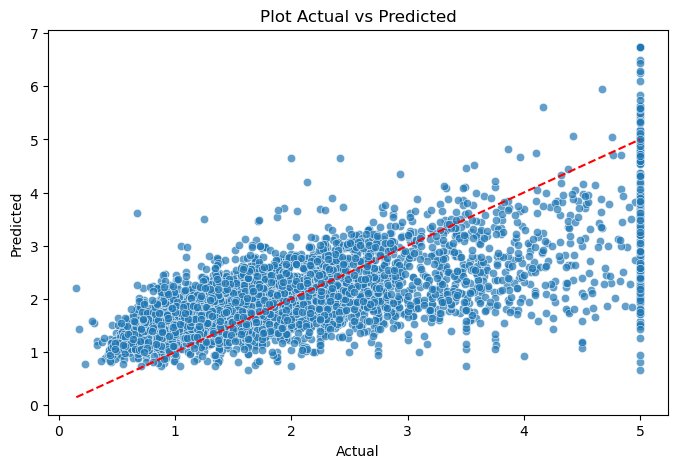

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction y=x')
plt.title('Plot Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()


**Task 3 — Multiple Linear Regression**
1. Gunakan seluruh fitur sebagai X (drop kolom MedHouseVal dari df). Gunakan split data yang sama (random_state=42).
2. Latih model LinearRegression baru dengan semua fitur.
3. Hitung metrik MAE, MSE, RMSE, dan R2 Score pada TRAINING set dan TEST set secara terpisah.
4. Buat tabel ringkasan di cell markdown yang membandingkan R2 Score Simple vs Multiple Linear Regression pada training dan test set.

In [14]:
#Task 3.1
X_new = df.drop(columns=['MedHouseVal'])
y_new = df['MedHouseVal']

X_new

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [15]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_new, y_new, random_state=42, test_size=0.2)

In [16]:
#Task 3.2
reg_model2 = LinearRegression().fit(X_train2, y_train2)
y_pred2 = reg_model2.predict(X_test2)
y_pred_train2 = reg_model2.predict(X_train2)

In [17]:
#Task 3.3
print(f'Metrik Test Set')
print(f'MAE: {mean_absolute_error(y_test2, y_pred2)}')
print(f'MSE: {mean_squared_error(y_test2, y_pred2)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test2, y_pred2))}')
print(f'R2: {r2_score(y_test2, y_pred2)}')

Metrik Test Set
MAE: 0.533200130495655
MSE: 0.5558915986952442
RMSE: 0.7455813830127763
R2: 0.575787706032451


In [18]:
print(f'Metrik Train Set')
print(f'MAE: {mean_absolute_error(y_train2, y_pred_train2)}')
print(f'MSE: {mean_squared_error(y_train2, y_pred_train2)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_train2, y_pred_train2))}')
print(f'R2: {r2_score(y_train2, y_pred_train2)}')

Metrik Train Set
MAE: 0.5286283596581919
MSE: 0.5179331255246699
RMSE: 0.7196757085831575
R2: 0.6125511913966952


**#Task 3.4**
| Model                        | R² Training | R² Test |
|-----------------------------|-------------|---------|
| Simple Linear Regression    | 0.45        | 0.47    |
| Multiple Linear Regression | 0.62        | 0.57    |


**Task 4 — Interpretasi dan Diagnosa Model**
1. Berdasarkan perbandingan R2 Train dan R2 Test di Task 3, tentukan apakah model termasuk underfitting, good fit, atau overfitting. Jelaskan dasar pemilihan Anda dalam 3 sampai 4 kalimat.
2. Hitung MAPE untuk model Multiple Linear Regression pada test set. Gunakan rumus: MAPE = mean(|actual - predicted| / actual) x 100.
3. Interpretasikan nilai MAPE tersebut: apa artinya secara bisnis jika model salah prediksi sebesar MAPE persen?
4. Tulis 2 sampai 3 kalimat tentang langkah perbaikan yang dapat dilakukan jika model dianggap kurang baik.

**#Task 4.1**\
Task 3.4 menjelaskan bahwa model Simple Linear Regression (SLR) merupakan underfitting, sedangkan model Multiple Linear Regression (MLR) merupakan good fit. SLR merupakan underfitting karena memiliki R² score yang rendah sehingga model terlalu sederhana dan tidak dapat menangkap pola data dengan baik. MLR memiliki R^2 score yang lebih mendekati satu sehingga lebih mampu untuk *generalize* data dengan baik.

In [19]:
#Task 4.2
print(f'MAPE: {np.mean(np.abs(y_test2 - y_pred2)/ y_test2)*100}')

MAPE: 31.952187413614908


**#Task 4.3**\
Dengan MAPE tersebut menentukan bahwa rata-rata prediksi rumah meleset sekitar 31.95% dari nilai aktual.\
Dalam konteks dataset ini, masih terdapat perbedaan yang cukup besar dari harga asli dengan harga prediksi sehingga akan mempengaruhi keputusan investasi dan penentuan harga rumah.

**#Task 4.4**\
Beberapa langkah yang dapat dilakukan adalah menggunakan model yang lebih kompleks dari Linear Regression. Selain itu, dapat dilakukan penambahan data yang lebih banyak dan menggunakan atau menambahkan fitur yang relevan ahar model dapat menangkap pola lebih baik